# Mrk 501 Localization

In [ ]:
%run setup_notebook.py
source_name = 'Mrk 501'

In [6]:
display(sedp[['flux', 'lflux', 'uflux', 'ts', 'maxdev']].round(1))

,flux,lflux,uflux,ts,maxdev
energy,,,,,
133,30.9,30.6,31.3,12332.2,0.0
237,9.6,9.4,9.7,8873.2,0.0
421,10.2,10.0,10.4,38797.4,0.0
749,8.6,8.4,8.7,3460.9,0.0
1333,9.2,9.0,9.4,3634.3,0.0
2371,10.4,10.3,10.6,6674.4,0.0
4216,10.9,10.6,11.3,4118.1,0.0
7498,13.2,12.7,13.7,2804.9,0.0
13335,14.7,14.0,15.4,4250.0,0.0


In [24]:
sed_all.query("elow==100")['flux lflux uflux'.split()].round(1)

,,flux,lflux,uflux
psf,energy,,,
PSF0,133,NaN,NaN,NaN
PSF1,133,NaN,NaN,NaN
PSF2,133,36.9,36.4,37.5
PSF3,133,26.4,26.0,26.9


initial: ra,dec, sigma:  166.1246   38.2064    0.1000
ts:        0.00 -55701.76 -53520.01 -52131.37 -46154.02 -44611.08 -51825.90 -54981.78 -55272.77
resid:    -0.00   -942.87   1114.82   -681.56   -103.11    779.55   -951.50    518.24    266.43
fit:       0.00     0.00    -1.31    -0.05     0.02  -130.50
chisq: 4459599.48
update:  ra,dec, sigma:  166.1128   38.2114    0.0011


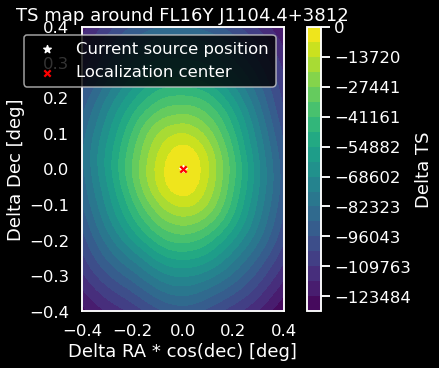

Localization result: <like3.quadform.Localize object at 0x7b47f8596120>
Localized position: <SkyCoord (ICRS): (ra, dec) in deg
    (166.11281358, 38.21135161)>


In [27]:
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import numpy as np

pt = study.pixel_table
target_name = str(selected_name)
src = pt.source_model.find_source(target_name)

loc = pt.localize(target_name, sigma=0.1, verbose=True)

if hasattr(loc, 'dir') and loc.dir is not None:
    src.skydir = loc.dir.coord if hasattr(loc.dir, 'coord') else loc.dir

def _to_skycoord(obj):
    return obj.coord if hasattr(obj, 'coord') else obj

center = _to_skycoord(src.skydir)
ra0, dec0 = center.ra.deg, center.dec.deg
size_deg = 0.4
nside = 41
dra = np.linspace(-size_deg, size_deg, nside)
ddec = np.linspace(-size_deg, size_deg, nside)
cosdec = max(abs(np.cos(np.radians(dec0))), 1e-6)

ll0 = pt.loglike()
ts_grid = np.zeros((nside, nside), dtype=float)
for iy, dy in enumerate(ddec):
    for ix, dx in enumerate(dra):
        trial = SkyCoord(
            ra=ra0 + dx / cosdec,
            dec=dec0 + dy,
            unit='deg',
            frame='icrs',
        )
        ts_grid[iy, ix] = 2.0 * (pt.loglike(skydir=trial) - ll0)

fig, ax = plt.subplots(figsize=(6, 5))
levels = np.linspace(np.nanmin(ts_grid), np.nanmax(ts_grid), 20)
contours = ax.contourf(dra, ddec, ts_grid, levels=levels, cmap='viridis')
ax.scatter([0], [0], c='white', s=60, marker='*', label='Current source position')

if hasattr(loc, 'dir') and loc.dir is not None:
    loc_sc = _to_skycoord(loc.dir)
    ax.scatter(
        [(loc_sc.ra.deg - ra0) * np.cos(np.radians(dec0))],
        [loc_sc.dec.deg - dec0],
        c='red',
        s=40,
        marker='x',
        label='Localization center',
    )

ax.set_xlabel('Delta RA * cos(dec) [deg]')
ax.set_ylabel('Delta Dec [deg]')
ax.set_title(f'TS map around {target_name}')
ax.legend(loc='best')
fig.colorbar(contours, ax=ax, label='Delta TS')
plt.show()

print('Localization result:', loc)
print('Localized position:', getattr(loc, 'dir', None))